In [14]:
# Cell 1: Setup and Imports

import os
import json
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
from tensorflow.keras.layers import Input, Embedding, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Model

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.15.0


In [15]:
# Cell 2: Download Dataset

import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
dataset_path = "shakespeare.txt"

urllib.request.urlretrieve(url, dataset_path)

with open(dataset_path, "r", encoding="utf-8") as f:
    text = f.read()

print("Text length:", len(text))
print(text[:1000])


Text length: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in 

Total characters: 1115394
Unique characters: 65

Top 20 most common characters:
' ' 169892
'e' 94611
't' 67009
'o' 65798
'a' 55507
'h' 51310
's' 49696
'r' 48889
'n' 48529
'i' 45537
'\n' 40000
'l' 33339
'd' 31358
'u' 26584
'm' 22243
'y' 20448
',' 19846
'w' 17585
'f' 15770
'c' 15623


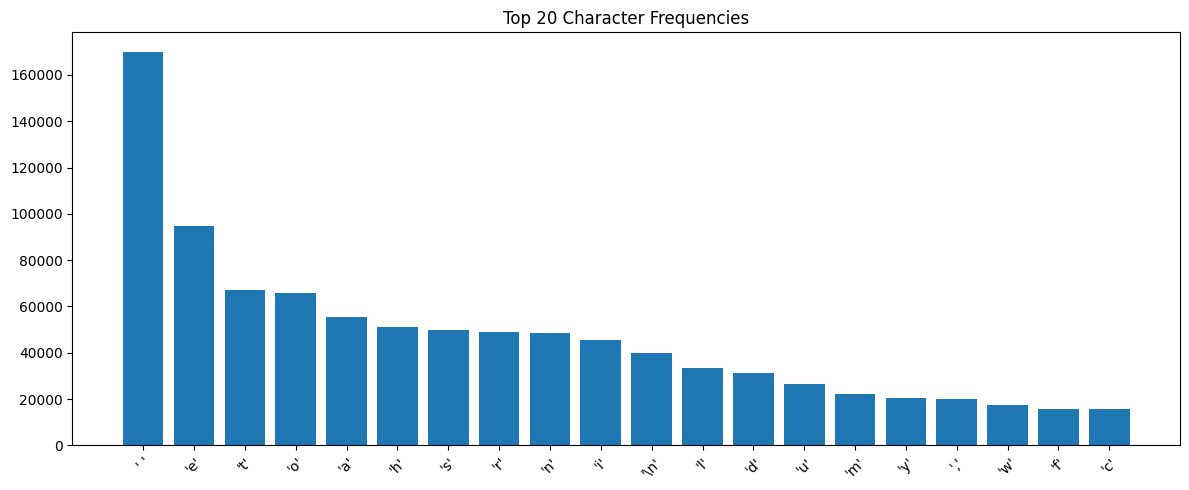

In [16]:
# Cell 3: Basic Text Analysis

total_chars = len(text)
unique_chars = sorted(list(set(text)))
vocab_size = len(unique_chars)

print("Total characters:", total_chars)
print("Unique characters:", vocab_size)

char_counts = Counter(text)
most_common = char_counts.most_common(20)
print("\nTop 20 most common characters:")
for ch, cnt in most_common:
    print(repr(ch), cnt)

plt.figure(figsize=(12, 5))
chars, counts = zip(*most_common)
plt.bar([repr(c) for c in chars], counts)
plt.title("Top 20 Character Frequencies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
# Cell 4: Create Mappings

char2idx = {ch: i for i, ch in enumerate(unique_chars)}
idx2char = {i: ch for ch, i in char2idx.items()}

print("Sample mapping:")
for ch in unique_chars[:10]:
    print(repr(ch), "->", char2idx[ch])

with open("char2idx.json", "w", encoding="utf-8") as f:
    json.dump(char2idx, f, ensure_ascii=False, indent=2)

with open("idx2char.json", "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in idx2char.items()}, f, ensure_ascii=False, indent=2)


Sample mapping:
'\n' -> 0
' ' -> 1
'!' -> 2
'$' -> 3
'&' -> 4
"'" -> 5
',' -> 6
'-' -> 7
'.' -> 8
'3' -> 9


In [18]:
# Cell 5: Create Sequences

seq_length = 100
stride = 3

input_sequences = []
target_chars = []

for i in range(0, len(text) - seq_length, stride):
    seq = text[i:i + seq_length]
    target = text[i + seq_length]
    input_sequences.append([char2idx[ch] for ch in seq])
    target_chars.append(char2idx[target])

print("Number of sequences:", len(input_sequences))

X = np.array(input_sequences, dtype=np.int32)
y = np.array(target_chars, dtype=np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)


Number of sequences: 371765
X shape: (371765, 100)
y shape: (371765,)


In [19]:
# Cell 6: Train-Validation Split

split_idx = int(0.9 * len(X))

X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Training samples: 334588
Validation samples: 37177


In [20]:
# Cell 7: Build tf.data Pipeline

batch_size = 128

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [21]:
# Cell 8: Build RNN Model

embedding_dim = 128
hidden_units = 256

inputs = Input(shape=(seq_length,))
x = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)
x = LSTM(hidden_units, return_sequences=True)(x)
x = Dropout(0.3)(x)
x = LSTM(hidden_units)(x)
x = Dropout(0.3)(x)
outputs = Dense(vocab_size, activation="softmax")(x)

model = Model(inputs, outputs)
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

model.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 100)]             0         
                                                                 
 embedding_1 (Embedding)     (None, 100, 128)          8320      
                                                                 
 lstm_2 (LSTM)               (None, 100, 256)          394240    
                                                                 
 dropout_2 (Dropout)         (None, 100, 256)          0         
                                                                 
 lstm_3 (LSTM)               (None, 256)               525312    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 65)                1670

In [22]:
# Cell 9: Optional GRU Model

def build_gru_model():
    inputs = Input(shape=(seq_length,))
    x = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)
    x = GRU(hidden_units, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = GRU(hidden_units)(x)
    x = Dropout(0.3)(x)
    outputs = Dense(vocab_size, activation="softmax")(x)
    gru_model = Model(inputs, outputs)
    gru_model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=["accuracy"]
    )
    return gru_model


In [23]:
# Cell 10: Custom Callback for Sampling

class TextGenerationCallback(Callback):
    def __init__(self, seed_text, every_n_epochs=5, gen_length=300):
        super().__init__()
        self.seed_text = seed_text
        self.every_n_epochs = every_n_epochs
        self.gen_length = gen_length

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n_epochs == 0:
            print("\n" + "=" * 80)
            print(f"Epoch {epoch+1}: Generated text")
            print(generate_text(self.model, self.seed_text, self.gen_length, temperature=0.8))
            print("=" * 80 + "\n")


In [24]:
# Cell 11: Sampling Functions

def sample_from_probs(probs, temperature=1.0, top_k=None, top_p=None):
    probs = np.asarray(probs).astype("float64")

    if temperature <= 0:
        return int(np.argmax(probs))

    probs = np.log(probs + 1e-9) / temperature
    probs = np.exp(probs)
    probs = probs / np.sum(probs)

    if top_k is not None:
        top_indices = np.argsort(probs)[-top_k:]
        top_probs = probs[top_indices]
        top_probs = top_probs / np.sum(top_probs)
        return np.random.choice(top_indices, p=top_probs)

    if top_p is not None:
        sorted_indices = np.argsort(probs)[::-1]
        sorted_probs = probs[sorted_indices]
        cum_probs = np.cumsum(sorted_probs)
        cutoff = np.where(cum_probs >= top_p)[0][0] + 1
        filtered_indices = sorted_indices[:cutoff]
        filtered_probs = probs[filtered_indices]
        filtered_probs = filtered_probs / np.sum(filtered_probs)
        return np.random.choice(filtered_indices, p=filtered_probs)

    return np.random.choice(len(probs), p=probs)

def generate_text(model, seed_text, gen_length=500, temperature=1.0, top_k=None, top_p=None):
    generated = seed_text
    current_text = seed_text

    for _ in range(gen_length):
        encoded = [char2idx.get(ch, 0) for ch in current_text[-seq_length:]]
        encoded = pad_sequences([encoded], maxlen=seq_length, padding="pre")
        preds = model.predict(encoded, verbose=0)[0]
        next_idx = sample_from_probs(preds, temperature=temperature, top_k=top_k, top_p=top_p)
        next_char = idx2char[next_idx]
        generated += next_char
        current_text += next_char

    return generated


In [25]:
# Cell 12: Callbacks and Checkpoints

os.makedirs("checkpoints", exist_ok=True)

checkpoint_cb = ModelCheckpoint(
    filepath="checkpoints/epoch_{epoch:02d}.weights.h5",
    save_weights_only=True,
    save_freq="epoch"
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

seed_text = text[:seq_length]
sample_cb = TextGenerationCallback(seed_text=seed_text, every_n_epochs=5, gen_length=300)


In [26]:
# Cell 13: Train the Model

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint_cb, early_stop_cb, sample_cb]
)


Epoch 1/30
2614/2614 [==============================] - 3531s 1s/step - loss: 2.1877 - accuracy: 0.3781 - val_loss: 1.8373 - val_accuracy: 0.4646
Epoch 2/30
2614/2614 [==============================] - 1840s 704ms/step - loss: 1.7474 - accuracy: 0.4850 - val_loss: 1.7034 - val_accuracy: 0.4975
Epoch 3/30
2614/2614 [==============================] - 3328s 1s/step - loss: 1.6223 - accuracy: 0.5164 - val_loss: 1.6478 - val_accuracy: 0.5080
Epoch 4/30
2614/2614 [==============================] - 1953s 747ms/step - loss: 1.5511 - accuracy: 0.5345 - val_loss: 1.6111 - val_accuracy: 0.5231
Epoch 5/30
2614/2614 [==============================] - ETA: 0s - loss: 1.5039 - accuracy: 0.5458
Epoch 5: Generated text
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
Your Same and father, sir, with advine And
accused a fault what her accused and in
That prove me are a thank you becomested,
And no sent thee are they marry's coudhath.

GREMIO:
Which we will

In [27]:
# Cell 14: Save Training History

history_dict = history.history

with open("training_history.json", "w", encoding="utf-8") as f:
    json.dump(history_dict, f, indent=2)

print(history_dict.keys())


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


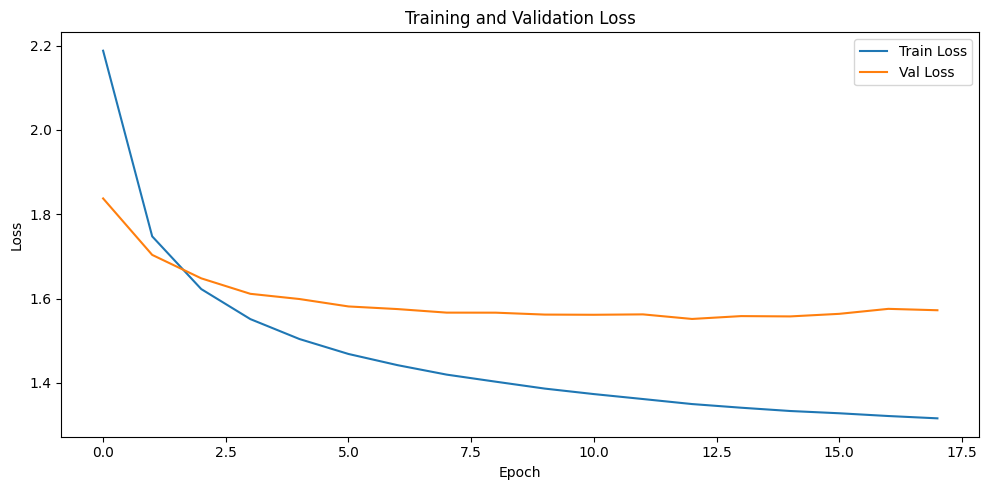

In [28]:
# Cell 15: Plot Loss Curves

plt.figure(figsize=(10, 5))
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)
plt.show()


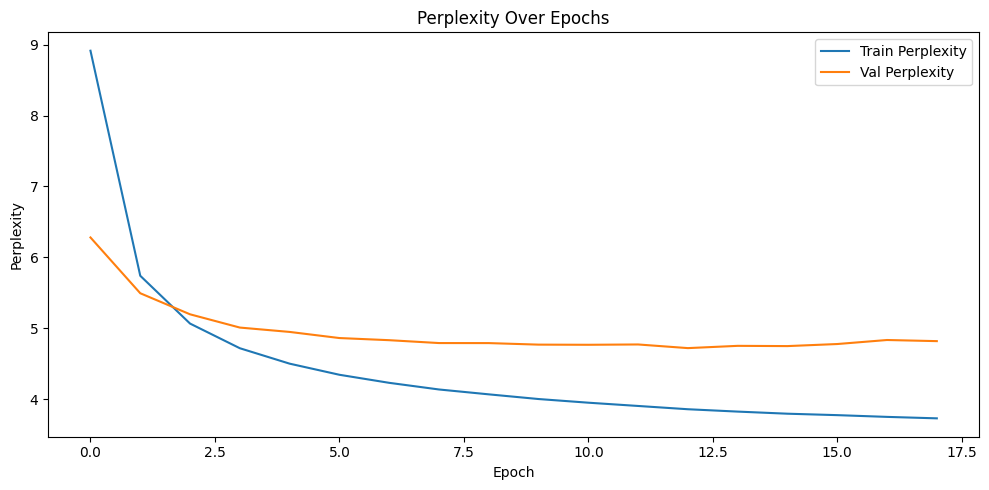

In [29]:
# Cell 16: Perplexity Plot

train_perplexity = [math.exp(loss) for loss in history_dict["loss"]]
val_perplexity = [math.exp(loss) for loss in history_dict["val_loss"]]

plt.figure(figsize=(10, 5))
plt.plot(train_perplexity, label="Train Perplexity")
plt.plot(val_perplexity, label="Val Perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Perplexity Over Epochs")
plt.legend()
plt.tight_layout()
plt.savefig("perplexity_curve.png", dpi=300)
plt.show()


In [30]:
# Cell 17: Generate Samples

seed_texts = [
    text[0:seq_length],
    text[1000:1000+seq_length],
    text[5000:5000+seq_length]
]

temperatures = [0.2, 0.5, 1.0, 1.2]

all_samples = []

for seed in seed_texts:
    for temp in temperatures:
        sample = generate_text(model, seed, gen_length=500, temperature=temp)
        all_samples.append(f"\n\n=== Seed ===\n{seed}\n\n=== Temperature {temp} ===\n{sample}\n")
        print(f"\nGenerated sample for temperature {temp}:\n")
        print(sample[:1000])

with open("generated_samples.txt", "w", encoding="utf-8") as f:
    f.writelines(all_samples)



Generated sample for temperature 0.2:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are she is the morn of her for the world.

LUCIO:
And say 'tis not the world and your house, I will not the
man be so many and the sense of the act
To the sense of my soul to see him and see,
And then the most subjects is the sense
To see him and the strength of the state,
And therefore he would not shall her heart
And there is the man of the strength of the beart,
And then the man should be so provost the father.

LUCIO:
And so will you so that I can see the love.

LUCIO:
A more shall be so mo

Generated sample for temperature 0.5:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are then was the worst gracious secrects.

DUKE VINCENTIO:
I may be so your father will not enduck,
That you will detive me as the more have good
And make him for the head of the aith of heavens,
And that as the sense 

In [31]:
# Cell 18: Top-k and Top-p Sampling

sample_topk = generate_text(model, seed_texts[0], gen_length=500, temperature=1.0, top_k=10)
sample_topp = generate_text(model, seed_texts[0], gen_length=500, temperature=1.0, top_p=0.9)

print("Top-k sample:\n", sample_topk[:1000])
print("\nTop-p sample:\n", sample_topp[:1000])


Top-k sample:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You did and yet her will make us for the hate,
Silkard such this walite, they that, for a life
Shall be the duke about what with him to come,
If if it to take my daughter for him?
What's your heart, fitted as if though say she dared;
And make will stuwn to defend for a power shall.

DUKE VINCENTIO:
No doubt and servants with him: incen nurse!

HORTENSIO:
Sirst if it shall be angelo!

DUKE VINCENTIO:
My father thing to be twinn to him, where's her:
My bawds have might have her man is sent a speed.



Top-p sample:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You mean, in your good would be of confite;
And that never in the rest, as if these tears.

GRUMIO:
Give her by your moust of Latisfice; doubt
Spake me like this limed a paste does so stand
Could.

First Lord:
And I'll not go; let's live by the men to
this is holy and ca

In [32]:
# Cell 19: Interactive Generation

def interactive_generate():
    user_seed = input("Enter seed text: ")
    gen_len = int(input("Enter generation length: "))
    temp = float(input("Enter temperature: "))
    result = generate_text(model, user_seed, gen_length=gen_len, temperature=temp)
    print("\nGenerated text:\n")
    print(result)

# Uncomment to use:
# interactive_generate()


In [33]:
# Cell 20: Save Model and Final Files

model.save("shakespeare_rnn_model.keras")
print("Model saved successfully.")


Model saved successfully.


In [34]:
# Cell 21: Optional Comparison Table

comparison_data = {
    "Model": ["LSTM", "GRU"],
    "Expected Strength": ["Better long-term memory", "Faster training"],
    "Expected Speed": ["Moderate", "Faster"],
    "Expected Text Quality": ["Often slightly better", "Often comparable"]
}

for i in range(len(comparison_data["Model"])):
    print(
        comparison_data["Model"][i],
        comparison_data["Expected Strength"][i],
        comparison_data["Expected Speed"][i],
        comparison_data["Expected Text Quality"][i]
    )


LSTM Better long-term memory Moderate Often slightly better
GRU Faster training Faster Often comparable
